In [3]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 17

train_dataset = image_dataset_from_directory(
    r'C:\Users\savan\Desktop\CS\یادگیری عمیق\17flowerclasses\train',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

test_dataset = image_dataset_from_directory(
    r'C:\Users\savan\Desktop\CS\یادگیری عمیق\17flowerclasses\test',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

class_names = train_dataset.class_names
print("Class Names:", class_names)


Found 1190 files belonging to 17 classes.
Found 170 files belonging to 17 classes.
Class Names: ['Bluebell', 'ButterCup', 'ColtsFoot', 'Cowslip', 'Crocus', 'Daffodil', 'Daisy', 'Dandelion', 'Fritillary', 'Iris', 'LilyValley', 'Pansy', 'Snowdrop', 'Sunflower', 'Tigerlily', 'WindFlower', 'tulip']


In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

data_augmentation = models.Sequential([
  layers.RandomFlip('horizontal'),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
])

base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False 

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 17)             │        21,777 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,279,761 (8.70 MB)

 Trainable params: 21,777 (85.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)

EPOCHS = 20
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 386ms/step - accuracy: 0.3420 - loss: 2.1480 - val_accuracy: 0.6529 - val_loss: 1.2359 - learning_rate: 0.0010
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 316ms/step - accuracy: 0.7353 - loss: 0.9561 - val_accuracy: 0.8000 - val_loss: 0.7809 - learning_rate: 0.0010
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 313ms/step - accuracy: 0.8252 - loss: 0.6429 - val_accuracy: 0.8176 - val_loss: 0.6089 - learning_rate: 0.0010
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 322ms/step - accuracy: 0.8672 - loss: 0.5004 - val_accuracy: 0.8353 - val_loss: 0.5251 - learning_rate: 0.0010
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 336ms/step - accuracy: 0.8916 - loss: 0.4209 - val_accuracy: 0.8529 - val_loss: 0.4717 - learning_rate: 0.0010
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 514ms/step - accuracy: 0.8899 - loss: 0.3653 - val_accuracy: 0.8529 - val_loss: 0.4436 - learning_rate: 0.0010
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 326ms/step - accuracy: 0.9084 - loss: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


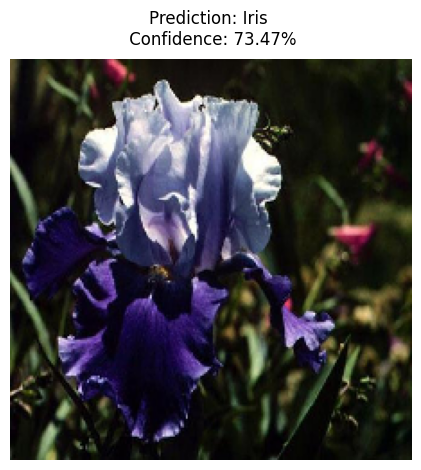

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

def predict_external_image(img_path, model, class_names):
    """
    تابعی برای پیش‌بینی کلاس یک تصویر خارجی با استفاده از مدل آموزش‌دیده.
    """

    if not os.path.exists(img_path):
        raise FileNotFoundError(f"مسیر تصویر یافت نشد: {img_path}")

    img = image.load_img(img_path, target_size=(224, 224))
    
    img_array = image.img_to_array(img)
    img_array_batch = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array_batch)
    predicted_class_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_index] * 100
    predicted_class_name = class_names[predicted_class_index]
    
    # ۶. نمایش خروجی
    # برای نمایش صحیح با Matplotlib، نوع داده مقادیر خام پیکسل باید uint8 باشد
    plt.imshow(img_array.astype("uint8"))
    plt.title(f"Prediction: {predicted_class_name} \n Confidence: {confidence:.2f}%", fontsize=12, pad=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

test_image_path = r"C:\Users\savan\Desktop\CS\یادگیری عمیق\17flowerclasses\test\Iris\image_0452.jpg"

predict_external_image(test_image_path, model, class_names)
